# Lab 5: Regression Analysis

## Aim
To implement Linear Regression using Python.

Step 1 = Load required libraries                         
Step 2 = Load the data            
Step 3 = Data Exploration        
Step 4 = Data Visualisation       
Step 5 = Divide the data intro training and testing             
Step 6 = Applying the machine    learning algorithm


In [4]:
# Step 1 :Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   # Visualization purpose
import seaborn as sns # Visualization purpose

import warnings
warnings.filterwarnings('ignore')

# Step 2 : Load the data

CRIM: per capita crime rate by town
ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS: proportion of non-retail business acres per town
CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
NOX: nitric oxides concentration (parts per 10 million)
RM: average number of rooms per dwelling
AGE: proportion of owner-occupied units built prior to 1940
DIS: weighted distances to five Boston employment centres
RAD: index of accessibility to radial highways
TAX: full-value property-tax rate per ($10,000)
PTRATIO: pupil-teacher ratio by town
B: 1000(Bk - 0.63)^2 where Bk is the proportion of [people of African American descent] by town
LSTAT: % lower status of the population
MEDV: Median value of owner-occupied homes in $1000s (target variable)

In [5]:
mydata = pd.read_csv('/content/Boston_HousingDataSet.xls')
mydata.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
# Step 3 : Data Exploration
mydata.shape

(506, 14)

In [7]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [8]:
## For checking null values
mydata.isna().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [9]:
mydata.describe()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: xlabel='MEDV', ylabel='Count'>

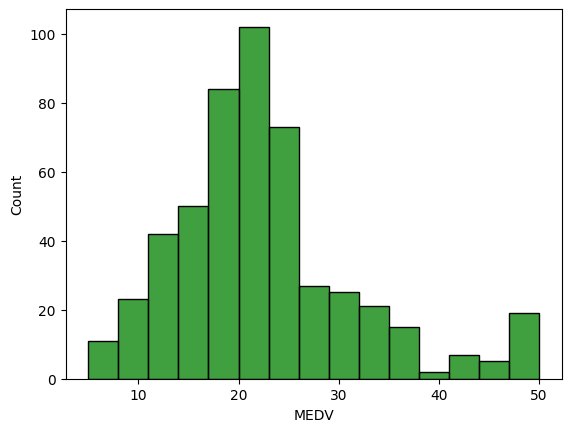

In [10]:
# Step 4 : Data Visualisation
# Histogram of target variable

sns.histplot(mydata['MEDV'],bins=15,color='green')

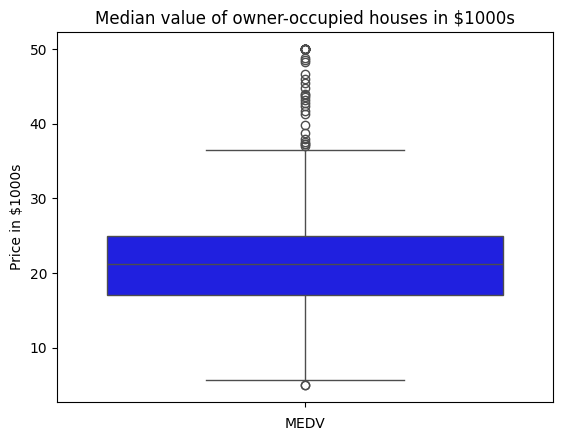

In [11]:
# Boxpolt of target variable
sns.boxplot(mydata['MEDV'],color='blue')
plt.title('Median value of owner-occupied houses in $1000s')
plt.xlabel('MEDV')
plt.ylabel('Price in $1000s')
plt.show()

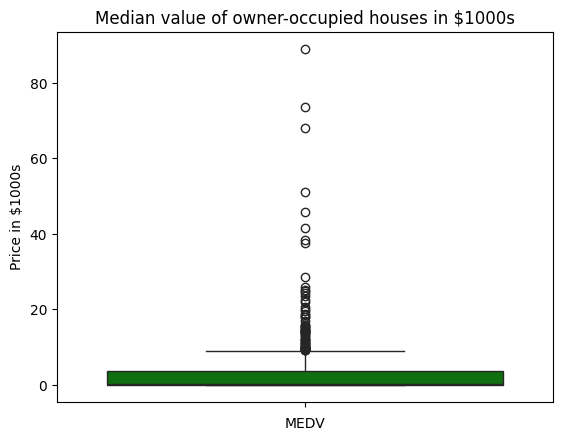

In [12]:
## boxplot crime rate
sns.boxplot(mydata['CRIM'],color='green')
plt.title('Median value of owner-occupied houses in $1000s')
plt.xlabel('MEDV')
plt.ylabel('Price in $1000s')
plt.show()

To install a Python library, you can use the `!pip install` command in a code cell. Replace `library_name` with the actual name of the library you want to install.

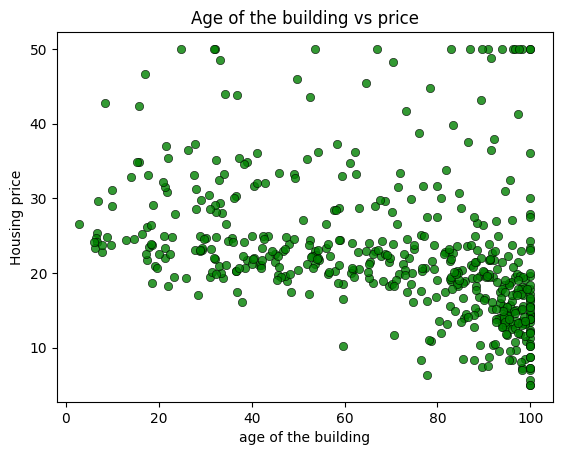

In [13]:
# Scatter plot
sns.scatterplot(x='AGE',y='MEDV',data=mydata,color='green',edgecolor='black',alpha=0.8)
plt.title('Age of the building vs price')
plt.xlabel('age of the building')
plt.ylabel('Housing price')
plt.show()

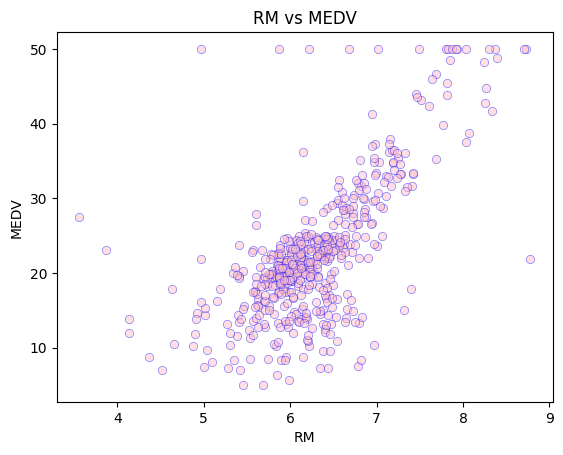

In [14]:
## Scaterplot between RM vs MEDV
sns.scatterplot(x='RM',y='MEDV',data=mydata,color='pink',edgecolor='blue',alpha=0.5)
plt.title('RM vs MEDV')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()


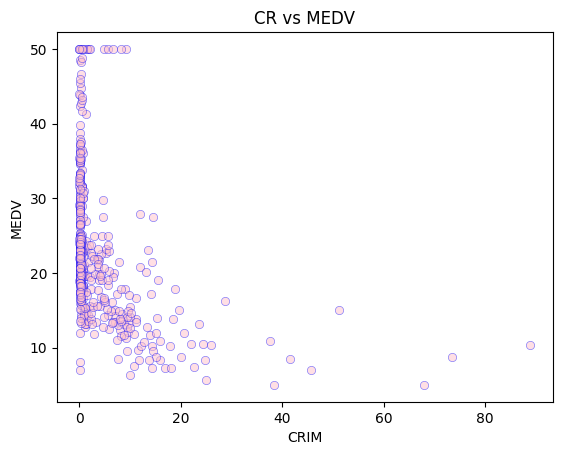

In [15]:
## Scaterplot between CRIM and MEDV
sns.scatterplot(x='CRIM',y='MEDV',data=mydata,color='pink',edgecolor='blue',alpha=0.5)
plt.title('CR vs MEDV')
plt.xlabel('CRIM')
plt.ylabel('MEDV')
plt.show()


In [16]:
mydata=pd.read_csv('/content/Boston_HousingDataSet.xls')
mydata.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [17]:
## Boxplot Average housing prices by accessibility of Road Highways

rad_medv_mean=mydata.groupby('RAD')['MEDV'].mean()
rad_medv_mean

,MEDV
RAD,
1,24.365000
2,26.833333
3,27.928947
4,21.387273
5,25.706957
6,20.976923
7,27.105882
8,30.358333
24,16.403788


<function seaborn.categorical.barplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, hue_norm=None, width=0.8, dodge='auto', gap=0, log_scale=None, native_scale=False, formatter=None, legend='auto', capsize=0, err_kws=None, ci=<deprecated>, errcolor=<deprecated>, errwidth=<deprecated>, ax=None, **kwargs)>

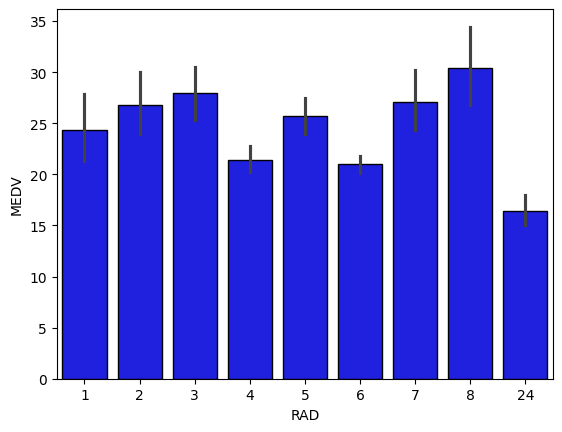

In [18]:
sns.barplot(x='RAD',y='MEDV',data=mydata,color='blue',edgecolor='black')
sns.barplot

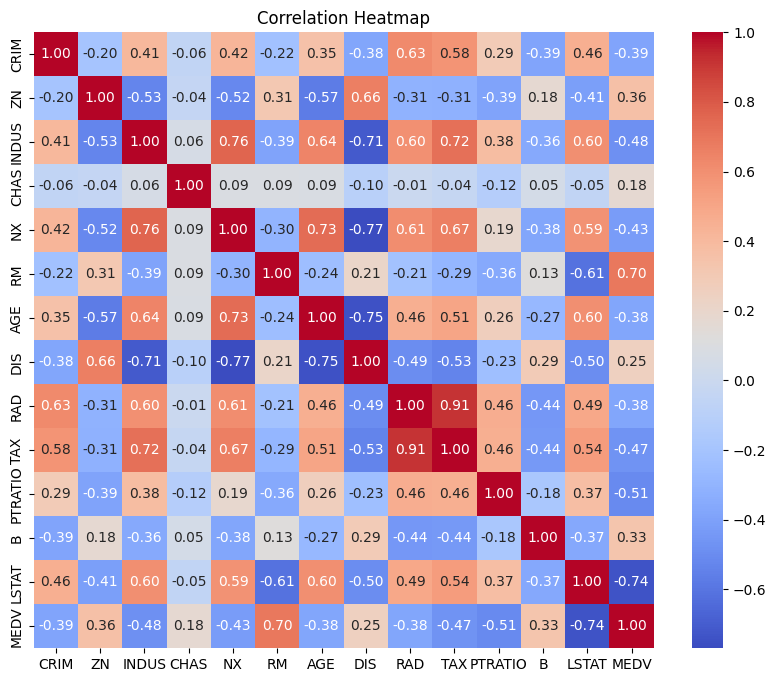

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create correlation matrix
corr = mydata.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,        # show numbers
            cmap='coolwarm',   # color theme
            fmt=".2f")         # 2 decimal values

plt.title("Correlation Heatmap")
plt.show()


<Axes: xlabel='RAD', ylabel='MEDV'>

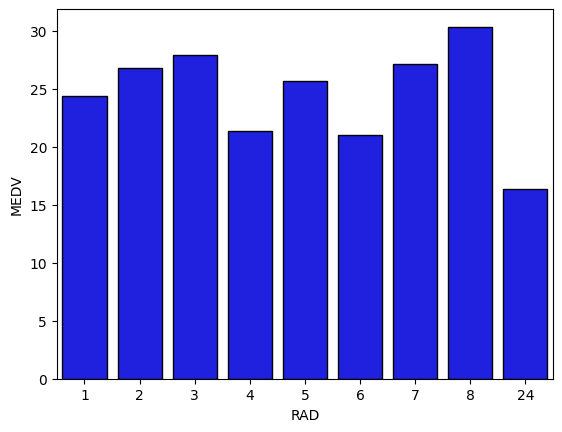

In [20]:
# Bar Plot
rad_medv_mean=mydata.groupby('RAD')['MEDV'].mean().reset_index()
sns.barplot(x='RAD',y='MEDV',data=rad_medv_mean, color='blue', edgecolor='black')

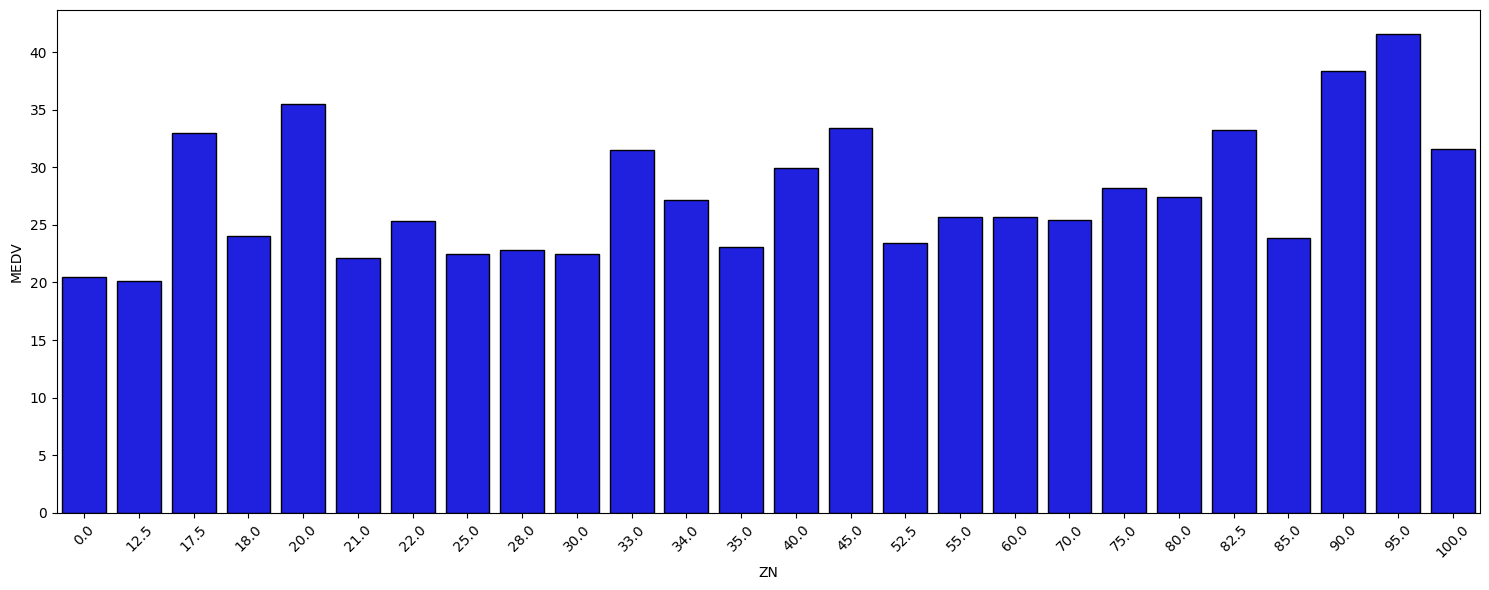

In [21]:
# Bar Plot

zn_medv_mean=mydata.groupby('ZN')['MEDV'].mean().reset_index()
figure_size=(15,6)
plt.figure(figsize=figure_size)
sns.barplot(x='ZN',y='MEDV',data=zn_medv_mean, color='blue', edgecolor='black')
plt.xticks(rotation=45)
plt.tight_layout()

In [22]:
x=mydata.drop(columns=['MEDV'])
y=mydata['MEDV']

In [23]:
x.shape
x.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [24]:
y.shape

(506,)

In [25]:
# Step 5 : Divide The Data into Training and Testing
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
x, y, test_size=0.3, random_state=3)

In [26]:
x_train.shape

(354, 13)

In [27]:
y_train.shape

(354,)

In [28]:
# Step 6 :  Applying machine learning algorithms

from sklearn.linear_model import LinearRegression

lr=LinearRegression()
ir_model=lr.fit(x_train, y_train)

In [29]:
ir_model.coef_

array([-1.28899229e-01,  4.62536564e-02, -5.41974027e-02,  3.83208843e+00,
       -1.24514995e+01,  3.72790367e+00,  7.37824474e-03, -1.19551784e+00,
        2.80152377e-01, -7.75364999e-03, -8.27122705e-01,  1.25331573e-02,
       -5.56644117e-01])

In [30]:
ir_model.intercept_

np.float64(28.744950121671945)

In [31]:
y_pred_lr = lr.predict(x_test)

In [32]:
from sklearn.metrics import r2_score as r2

r2_lr =r2(y_test, y_pred_lr)
r2_lr

0.714789526557684

In [33]:
# Decision Tree Algorithms

# Import libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Create model
dtr = DecisionTreeRegressor()

# Train model
dtr.fit(x_train, y_train)

# Predict
y_pred_dtr = dtr.predict(x_test)

# Calculate RMSE
rmse_dtr = np.sqrt(mean_squared_error(y_test, y_pred_dtr))

# Calculate R2 score
r2_dtr = r2_score(y_test, y_pred_dtr)




In [34]:
r2_dtr

0.7066317035989823

In [35]:
rmse_dtr

np.float64(4.803493794268808)

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

In [38]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Create Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(x_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(x_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MAPE:", mape_rf)
print("R^2 Score:", r2_rf)


Random Forest Results
MSE: 12.58224284210526
RMSE: 3.547145731726462
MAPE: 0.11543599024158287
R^2 Score: 0.840023285255153
